In [1]:
import numpy as np
import pandas as pd
import h5py

from SushiLife import *

In [2]:
# data_stock_df = read_db("../data/상장종목검색.db", date_format="%Y/%m/%d", num_process=6)
# data_value_df = read_db("../data/재무데이터(밸류).db", date_format="%Y/%m/%d", num_process=6)

# make_data("test.hdf5", "stock", data_stock_df, dtype="stock")
# make_data("test.hdf5", "value", data_value_df)

# del data_stock_df, data_value_df

In [3]:
f = h5py.File("test.hdf5", "r")
array_stock, axis_stock = load_data(f, "stock", chunks=5, in_memory=False)
array_value, axis_value = load_data(f, "value", chunks=5, in_memory=False)

data_stock = DataAsset(array_stock, axis_stock, chunks=5)
data_value = DataAsset(array_value, axis_value, chunks=5)

In [4]:
updater = Updater(pd.Timestamp(2002, 6, 15), data_stock.dates)

# 거래소 생성
exchange_stock = Exchange()
exchange_stock.set_DataAsset(data_stock)

# 주식 계좌 생성
stock_account = StockAccount(exchange_stock, 출력=False)

# 거래 에이전트 생성 및 주식 계좌 등록
agent = Agent(1e8, 출력=False)
agent.set_account("stock", stock_account)

# 날짜가 변할시 업데이트 요청
updater.set_instance4update(data_stock)
updater.set_instance4update(data_value)

updater.set_instance4update(exchange_stock)

updater.set_instance4update(agent)

# with pandas dataframe

In [5]:
%%time
updater.reset()
columns = ["상장시가총액(원)", "지배주주순이익(원)(직전4분기)", "지배주주지분(원)",
   "현금흐름(원)(직전4분기)", "매출액(원)(직전4분기)"]


while updater._date != updater._list_date[-1]:
    print(updater._date)
    fin_stat = data_value.get_info(updater._date, num=2,
                                 fields=columns)
    
    df = pd.DataFrame(fin_stat[-2], index=data_value.codes, columns=columns)
    df = df[~np.isnan(df["상장시가총액(원)"])] # 상장종목 고려 
    df = df.sort_values(by=['상장시가총액(원)']).iloc[:int(len(df.index) * 0.3)] # 소형주

    # 종목선정
    df["PER"] = df["상장시가총액(원)"] / df["지배주주순이익(원)(직전4분기)"]
    df["PBR"] = df["상장시가총액(원)"] / df["지배주주지분(원)"]
    df["PCR"] = df["상장시가총액(원)"] / df["현금흐름(원)(직전4분기)"]
    df["PSR"] = df["상장시가총액(원)"] / df["매출액(원)(직전4분기)"]

    df = df[df["PER"] > 0]
    df = df[df["PBR"] > 0]
    df = df[df["PCR"] > 0]
    df = df[df["PSR"] > 0]

    df["Rank"] = (df["PER"].rank() + df["PBR"].rank() + df["PCR"].rank() + df["PSR"].rank()).rank()

    df = df[df["Rank"] < 51]

    매수종목 = np.sort(df.index)

    # 매도
    매도종목 = list(agent.accounts["stock"].keys())
    현재가 = data_stock.get_info(updater._date, codes=매도종목, fields=["현재가"]).reshape(-1)
    매도수량 = [agent.accounts["stock"][종목코드]["보유수량"] for 종목코드 in 매도종목]
    agent.sell("stock", 매도종목, 현재가, 매도수량)

    # 매수
    현재가 = data_stock.get_info(updater._date, codes=매수종목, fields=["현재가"]).reshape(-1).astype("f")
    거래가능 = ~np.isnan(현재가)
    매수수량 = (agent.cash / 50 / 현재가[거래가능]).astype("i")
    agent.buy("stock", 매수종목[거래가능], 현재가[거래가능], 매수수량)
    
    for i in range(20):
        if updater._date == updater._list_date[-1]:
            break
        updater.update()

2002-06-17 00:00:00
2002-07-16 00:00:00
2002-08-14 00:00:00


C:\Users\wkwek\Dropbox\site-packages\systrading\backtest2\backtest\Exchnage.py:78: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  cond2 = (주문시간 == "장전") & (OCLHVVM[:, 0] >= 주문가격)  # 체결, 장 시작과 동시에 체결


2002-09-12 00:00:00
2002-10-14 00:00:00
2002-11-11 00:00:00
2002-12-09 00:00:00
2003-01-10 00:00:00
2003-02-10 00:00:00
2003-03-10 00:00:00
2003-04-07 00:00:00
2003-05-07 00:00:00
2003-06-05 00:00:00
2003-07-04 00:00:00
2003-08-04 00:00:00
2003-09-02 00:00:00
2003-10-06 00:00:00
2003-11-03 00:00:00
2003-12-01 00:00:00
2003-12-30 00:00:00
2004-02-03 00:00:00
2004-03-03 00:00:00
2004-03-31 00:00:00
2004-04-30 00:00:00
2004-06-01 00:00:00
2004-06-29 00:00:00
2004-07-27 00:00:00
2004-08-24 00:00:00
2004-09-21 00:00:00
2004-10-22 00:00:00
2004-11-19 00:00:00
2004-12-17 00:00:00
2005-01-17 00:00:00
2005-02-17 00:00:00
2005-03-18 00:00:00
2005-04-18 00:00:00
2005-05-17 00:00:00
2005-06-15 00:00:00
2005-07-13 00:00:00
2005-08-10 00:00:00
2005-09-08 00:00:00
2005-10-10 00:00:00
2005-11-07 00:00:00
2005-12-05 00:00:00
2006-01-03 00:00:00
2006-02-01 00:00:00
2006-03-02 00:00:00
2006-03-30 00:00:00
2006-04-27 00:00:00
2006-05-29 00:00:00
2006-06-28 00:00:00
2006-07-27 00:00:00
2006-08-25 00:00:00


In [6]:
레포트1 = pd.DataFrame(agent.report)
레포트1

,수익률(%),누적수익률(%),총자산(원),CAGR(%),일평균수익률(%),MDD,최대수익률(%),날짜
0,0.000000,0.000000,1.000000e+08,0.000000,0.000000,0.000000,0.000000,2002-06-17
1,0.168540,0.168540,1.001685e+08,35.978499,0.084235,0.000000,0.168540,2002-06-18
2,-3.710237,-3.547950,9.645205e+07,-98.766248,-1.196919,-3.710237,0.168540,2002-06-19
3,-0.011716,-3.559250,9.644075e+07,-96.337498,-0.901942,-3.721518,0.168540,2002-06-20
4,0.304513,-3.265575,9.673442e+07,-91.140342,-0.661817,-3.721518,0.168540,2002-06-21
5,-0.943175,-4.177950,9.582205e+07,-85.732052,-0.532047,-4.339177,0.168540,2002-06-24
6,-0.394486,-4.555955,9.544404e+07,-84.909528,-0.516772,-4.716546,0.168540,2002-06-25
7,-5.788591,-10.080820,8.991918e+07,-97.931715,-1.056964,-10.232115,0.168540,2002-06-26
8,0.793179,-9.367600,9.063240e+07,-96.175381,-0.890182,-10.232115,0.168540,2002-06-27
9,3.901646,-5.831445,9.416856e+07,-83.919311,-0.499448,-10.232115,0.168540,2002-06-28


# Pure numpy

dataframe을 사용하지 않고 numpy만 사용할 경우 3배까지 속도향상 가능

In [7]:
%%time
updater.reset()

columns = ["상장시가총액(원)", "지배주주순이익(원)(직전4분기)", "지배주주지분(원)",
   "현금흐름(원)(직전4분기)", "매출액(원)(직전4분기)"]

while updater._date != updater._list_date[-1]:
    print(updater._date)
    fin_stat = data_value.get_info(updater._date, num=2,
                             fields=columns)
    
    fin_stat = fin_stat[-2]
    상장시가총액 = fin_stat[:, 0]
    
    # 상장종목 고려
    상장종목 = ~np.isnan(상장시가총액)
    
    종목코드 = np.array(data_value.codes)[상장종목]
    상장시가총액 = 상장시가총액[상장종목]
    values = 상장시가총액.reshape(-1, 1) / fin_stat[상장종목, 1:]
    
    # 소형주
    시가총액순위 = 상장시가총액.argsort().argsort()
    시가총액조건 = 시가총액순위 < len(시가총액순위) * 0.3 # 상장종목 & 소형주
    
    values = values[시가총액조건, :]
    종목코드 = 종목코드[시가총액조건]
    
    # 양수
    cond_positive = (values > 0).all(axis=1)
    values = values[cond_positive, :]
    종목코드 = 종목코드[cond_positive]

    rank_each = values.argsort(axis=0).argsort(axis=0)
    sum_rank = np.sum(rank_each, axis=1)
    rank = sum_rank.argsort(axis=0).argsort(axis=0)

    cond_rank = rank < 50
    매수종목 = np.sort(종목코드[cond_rank])

    # 매도
    매도종목 = list(agent.accounts["stock"].keys())
    현재가 = data_stock.get_info(updater._date, codes=매도종목, fields=["현재가"]).reshape(-1)
    매도수량 = [agent.accounts["stock"][종목코드]["보유수량"] for 종목코드 in 매도종목]
    agent.sell("stock", 매도종목, 현재가, 매도수량)

    # 매수
    현재가 = data_stock.get_info(updater._date, codes=매수종목, fields=["현재가"]).reshape(-1).astype("f")
    거래가능 = ~np.isnan(현재가)
    매수수량 = (agent.cash / 50 / 현재가[거래가능]).astype("i")
    agent.buy("stock", 매수종목[거래가능], 현재가[거래가능], 매수수량)
    
    for i in range(20):
        if updater._date == updater._list_date[-1]:
            break
        updater.update()

C:\Users\wkwek\Dropbox\site-packages\systrading\backtest2\backtest\Agent.py:82: RuntimeWarning: overflow encountered in double_scalars
  CAGR = ((일평균수익률 / 100 + 1) ** 365 - 1) * 100
c:\users\wkwek\appdata\local\programs\python\python36\lib\site-packages\ipykernel_launcher.py:29: RuntimeWarning: invalid value encountered in greater
C:\Users\wkwek\Dropbox\site-packages\systrading\backtest2\backtest\Exchnage.py:78: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  cond2 = (주문시간 == "장전") & (OCLHVVM[:, 0] >= 주문가격)  # 체결, 장 시작과 동시에 체결


2002-06-17 00:00:00
2002-07-16 00:00:00
2002-08-14 00:00:00
2002-09-12 00:00:00
2002-10-14 00:00:00
2002-11-11 00:00:00
2002-12-09 00:00:00
2003-01-10 00:00:00
2003-02-10 00:00:00
2003-03-10 00:00:00
2003-04-07 00:00:00
2003-05-07 00:00:00
2003-06-05 00:00:00
2003-07-04 00:00:00
2003-08-04 00:00:00
2003-09-02 00:00:00
2003-10-06 00:00:00
2003-11-03 00:00:00
2003-12-01 00:00:00
2003-12-30 00:00:00
2004-02-03 00:00:00
2004-03-03 00:00:00
2004-03-31 00:00:00
2004-04-30 00:00:00
2004-06-01 00:00:00
2004-06-29 00:00:00
2004-07-27 00:00:00
2004-08-24 00:00:00
2004-09-21 00:00:00
2004-10-22 00:00:00
2004-11-19 00:00:00
2004-12-17 00:00:00
2005-01-17 00:00:00
2005-02-17 00:00:00
2005-03-18 00:00:00
2005-04-18 00:00:00
2005-05-17 00:00:00
2005-06-15 00:00:00
2005-07-13 00:00:00
2005-08-10 00:00:00
2005-09-08 00:00:00
2005-10-10 00:00:00
2005-11-07 00:00:00
2005-12-05 00:00:00
2006-01-03 00:00:00
2006-02-01 00:00:00
2006-03-02 00:00:00
2006-03-30 00:00:00
2006-04-27 00:00:00
2006-05-29 00:00:00


c:\users\wkwek\appdata\local\programs\python\python36\lib\site-packages\ipykernel_launcher.py:19: RuntimeWarning: divide by zero encountered in true_divide


2007-05-17 00:00:00
2007-06-18 00:00:00
2007-07-16 00:00:00
2007-08-14 00:00:00
2007-09-12 00:00:00
2007-10-16 00:00:00
2007-11-13 00:00:00
2007-12-11 00:00:00
2008-01-14 00:00:00
2008-02-14 00:00:00
2008-03-13 00:00:00
2008-04-11 00:00:00
2008-05-14 00:00:00
2008-06-12 00:00:00
2008-07-10 00:00:00
2008-08-07 00:00:00
2008-09-05 00:00:00
2008-10-07 00:00:00
2008-11-04 00:00:00
2008-12-02 00:00:00
2009-01-02 00:00:00
2009-02-03 00:00:00
2009-03-03 00:00:00
2009-03-31 00:00:00
2009-04-28 00:00:00
2009-05-28 00:00:00
2009-06-25 00:00:00
2009-07-23 00:00:00
2009-08-20 00:00:00
2009-09-17 00:00:00
2009-10-16 00:00:00
2009-11-13 00:00:00
2009-12-11 00:00:00
2010-01-13 00:00:00
2010-02-10 00:00:00
2010-03-12 00:00:00
2010-04-09 00:00:00
2010-05-10 00:00:00
2010-06-09 00:00:00
2010-07-07 00:00:00
2010-08-04 00:00:00
2010-09-01 00:00:00
2010-10-04 00:00:00
2010-11-01 00:00:00
2010-11-29 00:00:00
2010-12-27 00:00:00
2011-01-25 00:00:00
2011-02-25 00:00:00
2011-03-28 00:00:00
2011-04-25 00:00:00


In [8]:
레포트2 = pd.DataFrame(agent.report)
레포트2

,수익률(%),누적수익률(%),총자산(원),CAGR(%),일평균수익률(%),MDD,최대수익률(%),날짜
0,0.000000,0.000000,1.000000e+08,0.000000,0.000000,0.000000,0.000000,2002-06-17
1,0.168540,0.168540,1.001685e+08,35.978499,0.084235,0.000000,0.168540,2002-06-18
2,-3.710237,-3.547950,9.645205e+07,-98.766248,-1.196919,-3.710237,0.168540,2002-06-19
3,-0.011716,-3.559250,9.644075e+07,-96.337498,-0.901942,-3.721518,0.168540,2002-06-20
4,0.304513,-3.265575,9.673442e+07,-91.140342,-0.661817,-3.721518,0.168540,2002-06-21
5,-0.943175,-4.177950,9.582205e+07,-85.732052,-0.532047,-4.339177,0.168540,2002-06-24
6,-0.394486,-4.555955,9.544404e+07,-84.909528,-0.516772,-4.716546,0.168540,2002-06-25
7,-5.788591,-10.080820,8.991918e+07,-97.931715,-1.056964,-10.232115,0.168540,2002-06-26
8,0.793179,-9.367600,9.063240e+07,-96.175381,-0.890182,-10.232115,0.168540,2002-06-27
9,3.901646,-5.831445,9.416856e+07,-83.919311,-0.499448,-10.232115,0.168540,2002-06-28


In [9]:
import matplotlib.pyplot as plt

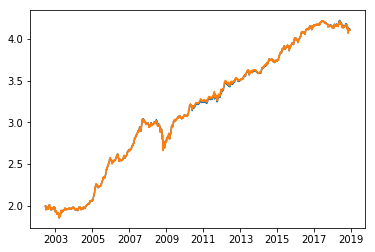

In [10]:
plt.plot(레포트1["날짜"], np.log10(레포트1["누적수익률(%)"] + 100))
plt.plot(레포트2["날짜"], np.log10(레포트2["누적수익률(%)"] + 100))

plt.show()